In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx

In [3]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo

from dask.distributed import Client

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
client = Client(n_workers=10, memory_limit="10 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36535 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36535/status,
Dashboard: http://127.0.0.1:36535/status,Workers: 10
Total threads: 10,Total memory: 100.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34843,Workers: 0
Dashboard: http://127.0.0.1:36535/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35469,Total threads: 1
Dashboard: http://127.0.0.1:42471/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:36523,


In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [6]:
DDF = True
DESI = True
refit_salt = True

In [7]:
columns = ["median_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec","Z_PHOT_MEAN_legacysurvey_dr10.1"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
if DESI:
    sncandid_filename = sncandid_filename+"_desi_gal"
sncat_meta = lsdb.open_catalog(sncandid_filename,columns=columns)

In [8]:
len(sncat_meta)

194

In [9]:
snmeta = sncat_meta.compute()

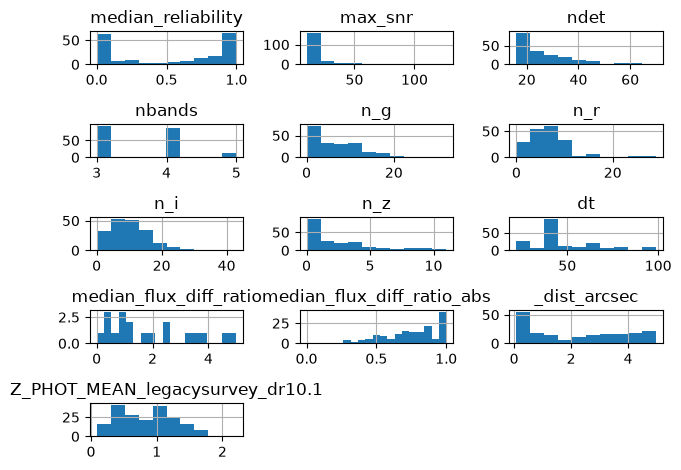

In [10]:
for i,col in enumerate(columns):
    plt.subplot(5,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(sncandid_filename,columns=bazin_cols)

In [12]:
snbazin = sncat_bazin.compute()

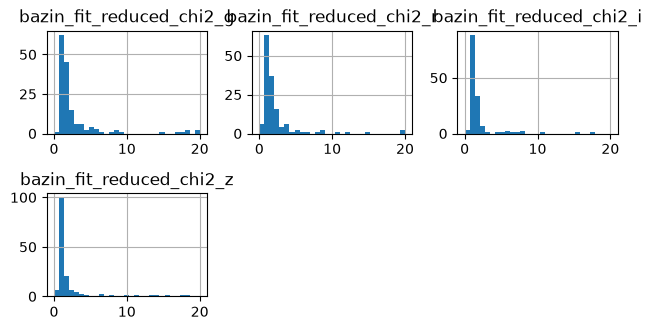

In [13]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [14]:
sncat = lsdb.open_catalog(sncandid_filename)

In [15]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 20.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 20.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 20.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 20.0))")
    return df

In [16]:
sn_good = sncat.map_partitions(filter_bazin)

In [17]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
if DESI:
    goodsn_filename = goodsn_filename+"_desi_gal"

In [18]:
sn_good.write_catalog(goodsn_filename,overwrite=True)

In [19]:
sn_good = lsdb.open_catalog(goodsn_filename)
sn_good = sn_good.compute()

In [20]:
sn_good

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
2391335229379053793         735947387813494802         63.604441   
2391379989965219878         737041951638945879         64.287977   
...                                        ...               ...   
2540738885684788994         755378026019029017         54.268523   
2542305618536473836         756867726835712032         54.100314   

                     dec_dia_object_lc  \
_healpix_29                              
2391335229379053793         -49.294894   
2391379989965219878         -49.009876   
...                                ...   
2540738885684788994         -27.713043   
2542305618536473836          -26.57981   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
2391335229379053793  [{midpointMjdTai: 60868.339863, band: 'g', psf...   
2391379989965219878  [{midpointMjdTai: 60868.3373, band: 'i', psfDi...   
...                                                                ...   
2540738885684788994  [{midpointMjdTai: 60868.330099, band: 'g', psf...   
2542305618536473836  [{midpointMjdTai: 60876.313564, band: 'i', psf...   

                                               diaSource_dia_object_lc  \
_healpix_29                                                              
2391335229379053793  [{midpointMjdTai: 60869.354317, band: 'r', psf...   
2391379989965219878  [{midpointMjdTai: 60874.326837, band: 'g', psf...   
...                                                                ...   
2540738885684788994  [{midpointMjdTai: 60868.334413, band: 'i', psf...   
2542305618536473836  [{midpointMjdTai: 60876.313564, band: 'i', psf...   

                     OBJID_legacysurvey_dr10.1 TYPE_legacysurvey_dr10.1  \
_healpix_29                                                               
2391335229379053793                      18410                      SER   
2391379989965219878                       6909                      REX   
...                                        ...                      ...   
2540738885684788994                       5723                      SER   
2542305618536473836                       2538                      REX   

                     Z_PHOT_MEAN_legacysurvey_dr10.1  \
_healpix_29                                            
2391335229379053793                         0.160708   
2391379989965219878                         1.578498   
...                                              ...   
2540738885684788994                         0.209251   
2542305618536473836                         0.782633   

                     Z_PHOT_STD_legacysurvey_dr10.1  \
_healpix_29                                           
2391335229379053793                         0.01983   
2391379989965219878                        0.659689   
...                                             ...   
2540738885684788994                         0.00913   
2542305618536473836                        0.098132   

                     Z_SPEC_legacysurvey_dr10.1  ...  bazin_fit_amplitude_z  \
_healpix_29                                      ...                          
2391335229379053793                       -99.0  ...           16322.803711   
2391379989965219878                       -99.0  ...           69805.804688   
...                                         ...  ...                    ...   
2540738885684788994                     0.20811  ...              123970.25   
2542305618536473836                       -99.0  ...            1876.155273   

                     bazin_fit_baseline_z  bazin_fit_reference_time_z  \
_healpix_29                                                             
2391335229379053793           -671.922241                  855.074585   
2391379989965219878          -8987.546875                   365.46936   
...                                   ...                   

In [21]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    plt.ylim(ylim)

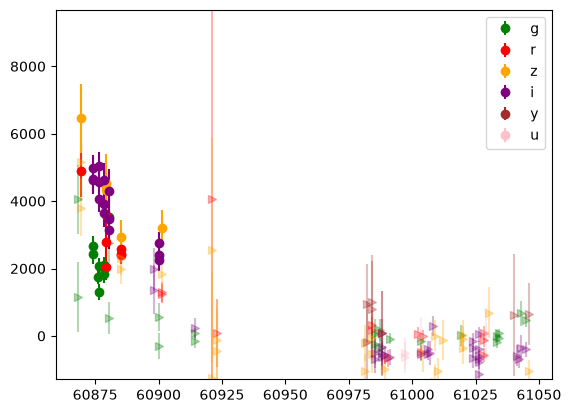

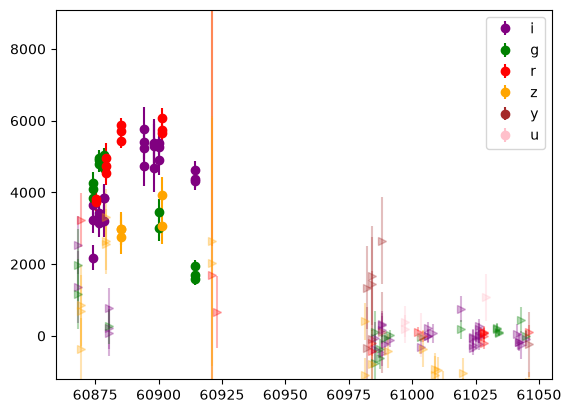

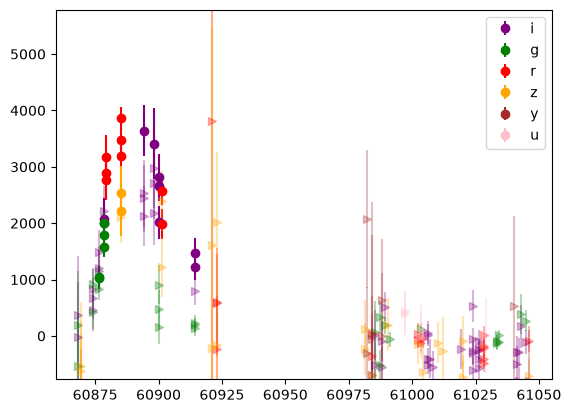

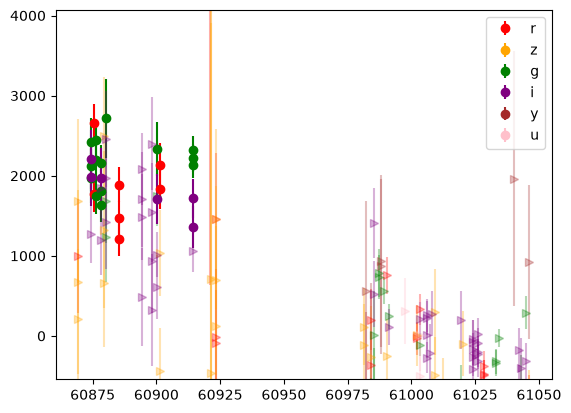

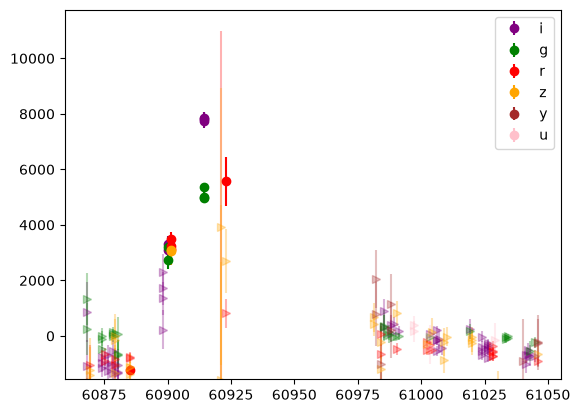

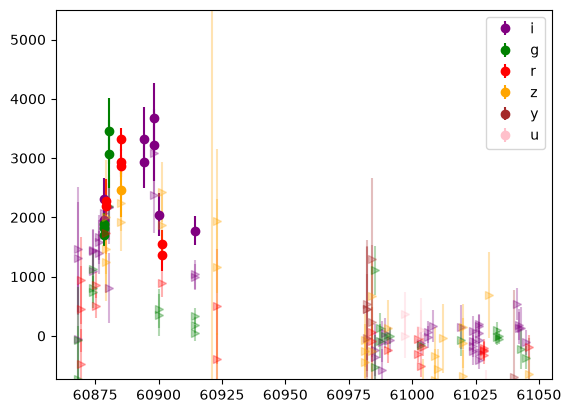

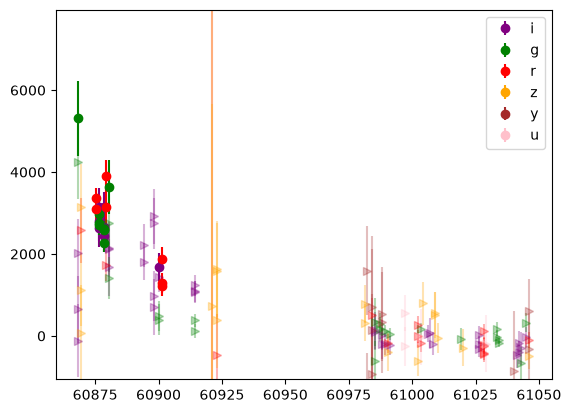

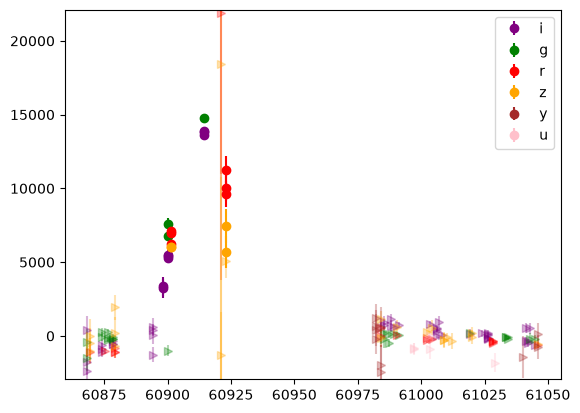

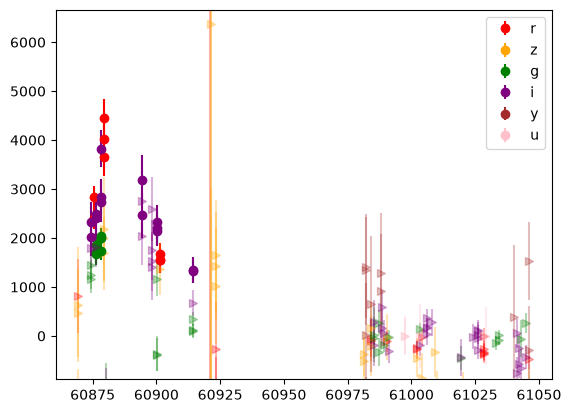

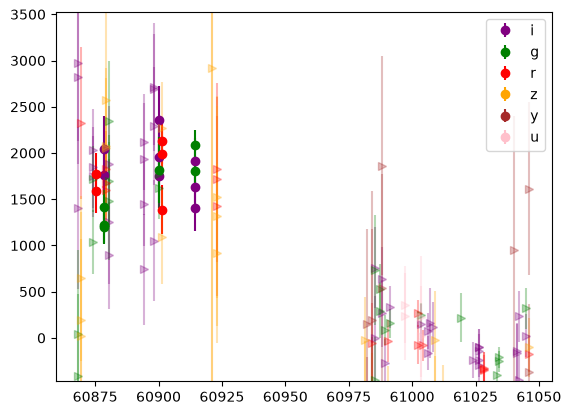

In [22]:
sn = sn_good
inds = np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False)
inds = np.arange(0,10)
for i in inds:
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [23]:
from lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [24]:
# def infer_z_from_peakmag(row):
#     peakflux = np.max(row)
#     peakmag = flux2mag(peakflux)
#     z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
#     return z

In [25]:
# sn_good = sn_good.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",output_names=["z_est"],
#                  append_columns=True)

In [26]:
# re-register passbands
from lightcurvelynx.astro_utils.passbands import PassbandGroup
passbands = PassbandGroup.from_preset("LSST", filters=['u','g', 'r', 'i', 'z', 'y'])
for passband in passbands:
    band = sncosmo.Bandpass(passband.transmission_table[passband.transmission_table[:, 1]>1.e-4, 0], 
                            passband.transmission_table[passband.transmission_table[:, 1]>1.e-4, 1], 
                            name='lynx_lsst_' + passband.filter_name)
    sncosmo.register(band, name='lynx_lsst_' + passband.filter_name, force=True)
    
sn_good["z_est"] = sn_good["Z_PHOT_MEAN_legacysurvey_dr10.1"]
sn_good["z_est_err"] = sn_good["Z_PHOT_STD_legacysurvey_dr10.1"]
res = sn_good.iloc[0:10].map_rows(fit_single_lc_w_cond, 
                       columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", 
                                "z_est","z_est_err",
                                "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                       append_columns=False)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_g, lynx_lsst_r(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_r, lynx_lsst_g(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_g, lynx_lsst_r, lynx_lsst_i(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +


In [27]:
res

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,x1,x1_err,c,c_err,mwebv,mwebv_err,z_z_cov,z_t0_cov,z_x0_cov,z_x1_cov,z_c_cov,z_mwebv_cov,t0_z_cov,t0_t0_cov,t0_x0_cov,t0_x1_cov,t0_c_cov,t0_mwebv_cov,x0_z_cov,x0_t0_cov,x0_x0_cov,x0_x1_cov,x0_c_cov,x0_mwebv_cov,x1_z_cov,x1_t0_cov,x1_x0_cov,x1_x1_cov,x1_c_cov,x1_mwebv_cov,c_z_cov,c_t0_cov,c_x0_cov,c_x1_cov,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
_healpix_29,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2391335229379053793,1.0,284.0,72.098937,29.0,0.126645,0.009501,60848.427392,0.965506,0.000107,5.932654e-06,-1.843510,0.148890,-0.399999,0.090061,0.010325,0.0,0.000091,-0.001337,-6.317873e-09,1.498681e-04,-2.117448e-08,0.0,-0.001337,0.932304,-4.627106e-06,-3.574073e-02,-0.000001,0.0,-6.317873e-09,-4.627106e-06,3.519638e-11,-1.831660e-07,-6.593048e-11,0.0,1.498681e-04,-3.574073e-02,-1.831660e-07,2.218126e-02,1.671405e-06,0.0,-2.117448e-08,-0.000001,-6.593048e-11,1.671405e-06,2.293853e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,735947387813494802,None
2391379989965219878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737041951638945879,RuntimeError('No bands in data overlap the model.')
2391392038739213025,1.0,232.0,23.025793,20.0,0.558089,0.029270,60889.387532,0.597924,0.000011,6.379026e-07,0.140682,0.781209,-0.244773,0.043295,0.011093,0.0,0.000871,0.007596,-1.254091e-08,6.859257e-03,-8.833877e-04,0.0,0.007596,0.357522,-1.558985e-07,1.522504e-01,-0.019789,0.0,-1.254091e-08,-1.558985e-07,4.069197e-13,-3.940244e-07,1.530820e-08,0.0,6.859257e-03,1.522504e-01,-3.940244e-07,6.182185e-01,-6.774508e-03,0.0,-8.833877e-04,-0.019789,1.530820e-08,-6.774508e-03,1.886283e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737042707553190055,None
2391392957835367486,1.0,556.0,3.136963,3.0,0.904589,0.045493,60890.689334,1.786905,0.000007,4.929353e-07,4.000000,0.839547,0.399470,0.599350,0.011879,0.0,0.002071,0.006012,6.799099e-09,-3.786291e-11,1.932612e-05,0.0,0.006012,3.193537,-1.591865e-08,1.856282e-09,-0.005137,0.0,6.799099e-09,-1.591865e-08,2.429852e-13,4.839327e-15,2.365329e-08,0.0,-3.786291e-11,1.856282e-09,4.839327e-15,1.298140e-10,-2.825718e-12,0.0,1.932612e-05,-0.005137,2.365329e-08,-2.825718e-12,9.206438e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737043394747957324,None
2391401499306183259,1.0,72.0,0.079645,-2.0,0.873012,0.614052,60925.535021,15.438616,0.000018,4.089461e-06,3.882256,6.898654,-0.233867,0.417026,0.011584,0.0,0.423948,2.544559,-6.578753e-07,-5.832785e-01,1.041030e-01,0.0,2.544559,243.058714,1.691841e-05,1.451542e+01,-2.689787,0.0,-6.578753e-07,1.691841e-05,1.672369e-11,-3.752565e-06,6.912514e-07,0.0,-5.832785e-01,1.451542e+01,-3.752565e-06,1.462685e+01,5.932938e-01,0.0,1.041030e-01,-2.689787,6.912514e-07,5.932938e-01,4.187276e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737043944503771460,None
2394418173973190433,1.0,228.0,33.872151,19.0,0.330706,0.021788,60886.874426,0.564313,0.000011,5.198395e-07,-0.286520,0.704462,0.000022,0.058158,0.015790,0.0,0.000477,0.003229,-5.027417e-09,3.875646e-03,-7.979981e-04,0.0,0.003229,0.318457,4.173889e-08,1.537083e-01,-0.015842,0.0,-5.027417e-09,4.173889e-08,2.702331e-13,-2.196832e-07,-3.035872e-09,0.0,3.875646e-03,1.537083e-01,-2.196832e-07,5.015108e-01,7.699400e-06,0.0,-7.979981e-04,-0.015842,-3.035872e-09,7.699400e-06,3.406513e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737046006088073410,None
2394426097777813188,1.0,621.0,19.704712,18.0,0.251350,0.219438,60869.748745,2.778066,0.000014,8.233664e-07,3.661582,0.998307,-0.060613,0.035586,0.009330,0.0,0.000013,0.000209,-1.383241e-10,2.131004e-04,-1.721620e-05,0.0,0.000209,7.721513,-1.347631e-06,-1.619630e+00,0.027782,0.0,-1.383241e-10,-1.347631e-06,6.779323e-13,-2.379455e-07,-1.486921e-08,0.0,2.131004e-04,-1.619630e+00,-2.379455e-07,1.159466e+00,6.299062e-03,0.0,-1.721620e-05,0.027782,-1.486921e-08,6.299062e-03,1.2697

In [28]:
if DESI:
    desi_str = "_desi_gal"
else:
    desi_str = ""
if DDF:
    res_filename = f"saltfit_good_sne_ddf{desi_str}.parquet"
else:
    res_filename = f"saltfit_good_sne{desi_str}.parquet"

In [29]:
sn_to_fit = sn_good

In [30]:
if refit_salt:
    # results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in sn_to_fit.iterrows())
    results = sn_to_fit.map_rows(fit_single_lc_w_cond, 
                       columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", 
                                "z_est", "z_est_err",
                                "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                       append_columns=False)
    result_df = pd.DataFrame(results)
    result_df.to_parquet(res_filename)
else:
    result_df = pd.read_parquet(res_filename)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_g, lynx_lsst_r(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_r, lynx_lsst_g(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_g, lynx_lsst_r, lynx_lsst_i(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_g(out of model wavelength range)
  warnings.warn("Dropping followi

In [31]:
result_df

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
_healpix_29,,,,,,,,,,,,,,,,,,,,,
2391335229379053793,1.0,284.0,72.098937,29.0,0.126645,0.009501,60848.427392,0.965506,0.000107,0.000006,...,2.293853e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,735947387813494802,None
2391379989965219878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737041951638945879,RuntimeError('No bands in data overlap the mod...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540738885684788994,1.0,547.0,16.895122,16.0,0.182709,0.038813,60863.678236,1.368306,0.000016,0.000001,...,6.249096e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,755378026019029017,None
2542305618536473836,1.0,106.0,5.598430,4.0,0.799575,0.385913,60894.684548,14.453445,0.000007,0.000005,...,6.689764e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,756867726835712032,None


In [32]:
result_good = result_df.loc[result_df.success == 1]

In [33]:
result_good

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
_healpix_29,,,,,,,,,,,,,,,,,,,,,
2391335229379053793,1.0,284.0,72.098937,29.0,0.126645,0.009501,60848.427392,0.965506,0.000107,5.932654e-06,...,2.293853e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,735947387813494802,None
2391392038739213025,1.0,232.0,23.025793,20.0,0.558089,0.029270,60889.387532,0.597924,0.000011,6.379026e-07,...,1.886283e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,737042707553190055,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540738885684788994,1.0,547.0,16.895122,16.0,0.182709,0.038813,60863.678236,1.368306,0.000016,1.260748e-06,...,6.249096e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,755378026019029017,None
2542305618536473836,1.0,106.0,5.598430,4.0,0.799575,0.385913,60894.684548,14.453445,0.000007,4.551844e-06,...,6.689764e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,756867726835712032,None


In [34]:
result_good = result_good.loc[(np.absolute(result_good.x1) < 3.99) & (np.absolute(result_good.c) < 0.399)]

<Axes: >

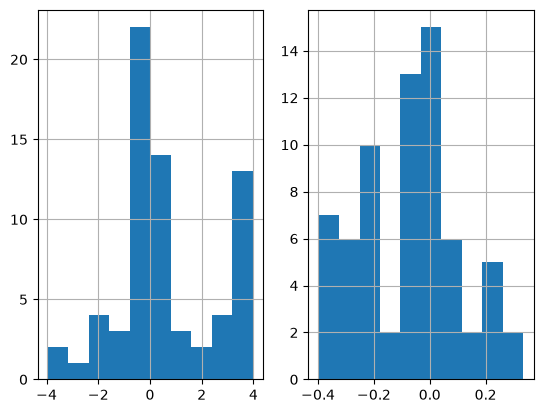

In [35]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [36]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

<Axes: >

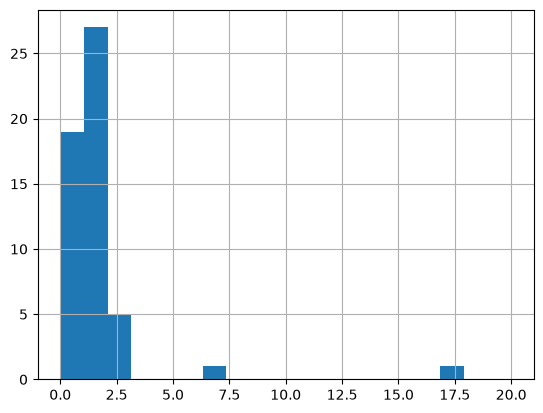

In [37]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 20, 20))

In [38]:
result_good = result_good.loc[(result_good.reduced_chisq > 0.1) & (result_good.reduced_chisq < 10.)]

In [39]:
sn_good = sn_good.loc[result_good.index]

In [40]:
sn_good

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
2391392038739213025         737042707553190055         64.063787   
2394418173973190433         737046006088073410         64.438225   
...                                        ...               ...   
2530036359826379866         755362839014671226         51.156666   
2542305618536473836         756867726835712032         54.100314   

                     dec_dia_object_lc  \
_healpix_29                              
2391392038739213025         -48.733135   
2394418173973190433         -47.950464   
...                                ...   
2530036359826379866         -28.125963   
2542305618536473836          -26.57981   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
2391392038739213025  [{midpointMjdTai: 60868.3373, band: 'i', psfDi...   
2394418173973190433  [{midpointMjdTai: 60868.336866, band: 'i', psf...   
...                                                                ...   
2530036359826379866  [{midpointMjdTai: 60868.330099, band: 'g', psf...   
2542305618536473836  [{midpointMjdTai: 60876.313564, band: 'i', psf...   

                                               diaSource_dia_object_lc  \
_healpix_29                                                              
2391392038739213025  [{midpointMjdTai: 60876.318537, band: 'g', psf...   
2394418173973190433  [{midpointMjdTai: 60876.327006, band: 'i', psf...   
...                                                                ...   
2530036359826379866  [{midpointMjdTai: 61020.239061, band: 'z', psf...   
2542305618536473836  [{midpointMjdTai: 60876.313564, band: 'i', psf...   

                     OBJID_legacysurvey_dr10.1 TYPE_legacysurvey_dr10.1  \
_healpix_29                                                               
2391392038739213025                       7456                      REX   
2394418173973190433                      19898                      SER   
...                                        ...                      ...   
2530036359826379866                       4525                      SER   
2542305618536473836                       2538                      REX   

                     Z_PHOT_MEAN_legacysurvey_dr10.1  \
_healpix_29                                            
2391392038739213025                          0.44754   
2394418173973190433                         0.277016   
...                                              ...   
2530036359826379866                         0.110794   
2542305618536473836                         0.782633   

                     Z_PHOT_STD_legacysurvey_dr10.1  \
_healpix_29                                           
2391392038739213025                        0.057907   
2394418173973190433                        0.070089   
...                                             ...   
2530036359826379866                        0.018834   
2542305618536473836                        0.098132   

                     Z_SPEC_legacysurvey_dr10.1  ...  \
_healpix_29                                      ...   
2391392038739213025                       -99.0  ...   
2394418173973190433                       -99.0  ...   
...                                         ...  ...   
2530036359826379866                       -99.0  ...   
2542305618536473836                       -99.0  ...   

                     bazin_fit_reference_time_z  bazin_fit_rise_time_z  \
_healpix_29                                                              
2391392038739213025                  871.051575               0.349354   
2394418173973190433                  722.911133              79.348763   
...                                         ...                    ...   
2530036359826379866                    1030.875               0.303711   
2542305618536473836                  954.489929               8.75175

In [41]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [42]:
sn_good["z"] = result_good["z"].values
sn_good["t0"] = result_good["t0"].values
sn = sn_good
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [43]:
len(sn)

26

{'x0': np.float64(1.0590829443265695e-05), 'x1': np.float64(0.14068180916854764), 'c': np.float64(-0.24477276332645198), 'z': np.float64(0.5580892778034632), 'mwebv': np.float64(0.011093491400500866), 't0': np.float64(60889.38753206592)}
0.770867272560266


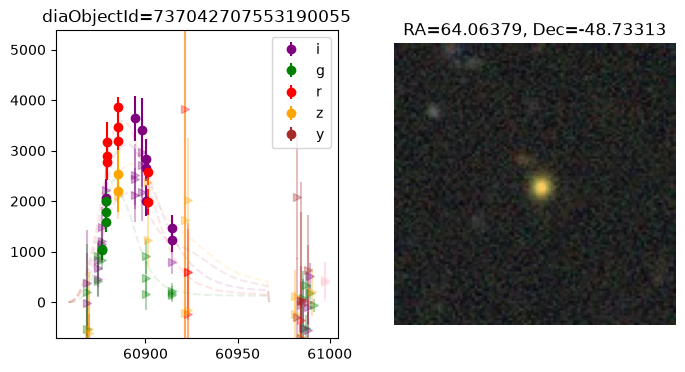

{'x0': np.float64(7.823925890488172e-06), 'x1': np.float64(3.748547796593075), 'c': np.float64(-0.04548805469636333), 'z': np.float64(0.490662277783711), 'mwebv': np.float64(0.0063511606516360114), 't0': np.float64(61006.15787121544)}
1.0581446763548135


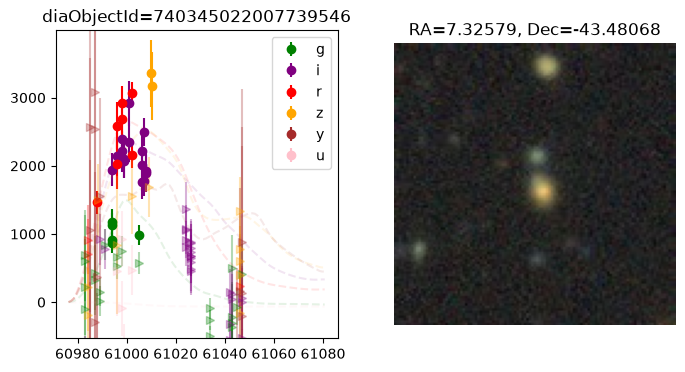

{'x0': np.float64(2.554955153517128e-05), 'x1': np.float64(-1.221232112920136), 'c': np.float64(-0.0878617056959533), 'z': np.float64(0.34231002010499634), 'mwebv': np.float64(0.012360086163422422), 't0': np.float64(60878.72758096206)}
0.47269271011547426


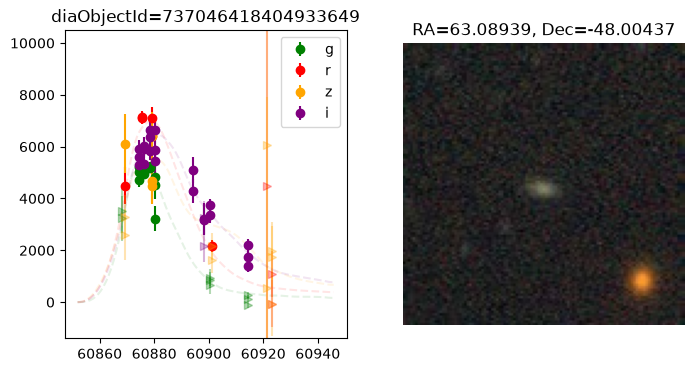

{'x0': np.float64(9.472352663830637e-06), 'x1': np.float64(-0.6836114828972508), 'c': np.float64(-0.22153482196522586), 'z': np.float64(0.5857465661694885), 'mwebv': np.float64(0.007499664672952875), 't0': np.float64(60861.46984455149)}
0.19413748770772712


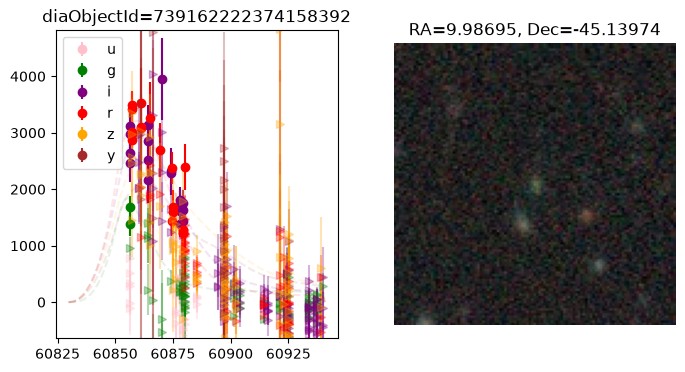

{'x0': np.float64(1.2539516291708416e-05), 'x1': np.float64(-0.20977220064242244), 'c': np.float64(0.0839367685235578), 'z': np.float64(0.3835108014611175), 'mwebv': np.float64(0.011960432143179375), 't0': np.float64(60885.22753602368)}
3.3277608584297056


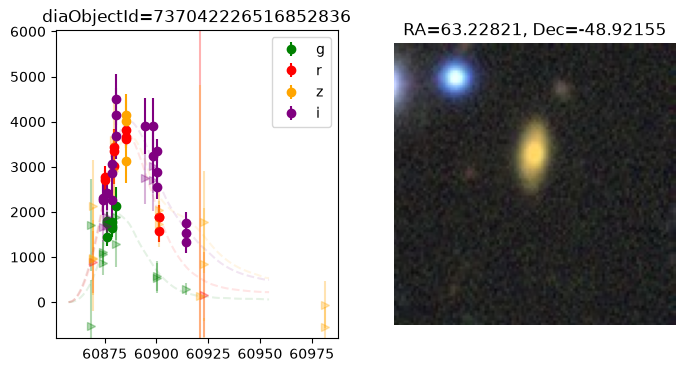

{'x0': np.float64(8.30203257587257e-06), 'x1': np.float64(-0.08322078888774757), 'c': np.float64(-0.23058731353895945), 'z': np.float64(0.5940946011427368), 'mwebv': np.float64(0.0051558707836493), 't0': np.float64(60867.76474257456)}
0.3435966082338456


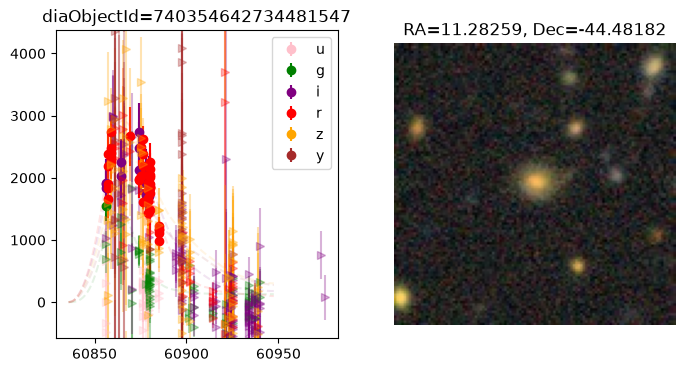

{'x0': np.float64(1.364888783193631e-05), 'x1': np.float64(3.661582246768276), 'c': np.float64(-0.060613399302527314), 'z': np.float64(0.25135043091165055), 'mwebv': np.float64(0.009330228778034326), 't0': np.float64(60869.748744513774)}
0.6394311486103694


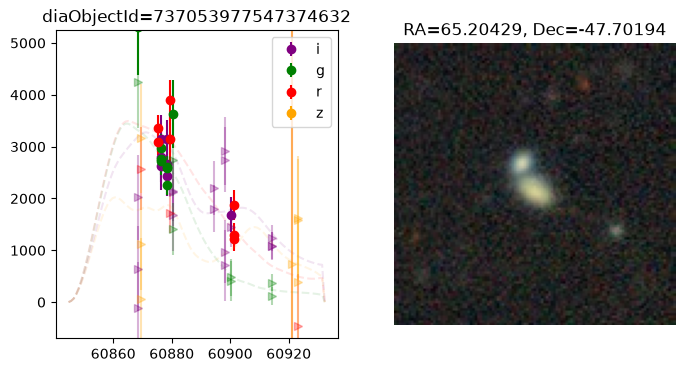

{'x0': np.float64(1.202758351011874e-05), 'x1': np.float64(-2.0901188107488475), 'c': np.float64(-0.32035189088100646), 'z': np.float64(0.40956895714147196), 'mwebv': np.float64(0.010473309593238599), 't0': np.float64(60896.903859659804)}
0.6585999902461073


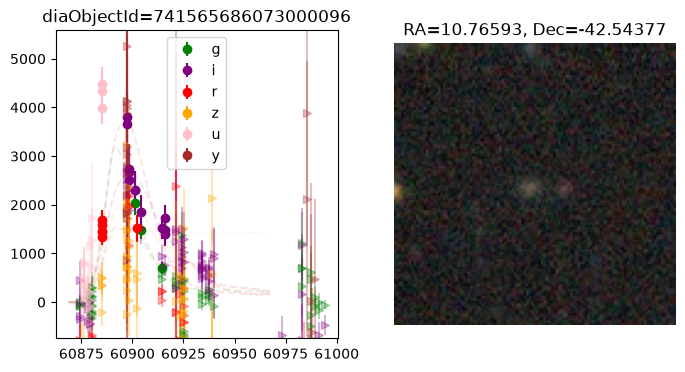

{'x0': np.float64(1.0462005784452238e-05), 'x1': np.float64(1.0167385577542905), 'c': np.float64(0.20400053319301317), 'z': np.float64(0.611477899487126), 'mwebv': np.float64(0.006393236211938459), 't0': np.float64(60885.8512841403)}
2.059195922379052


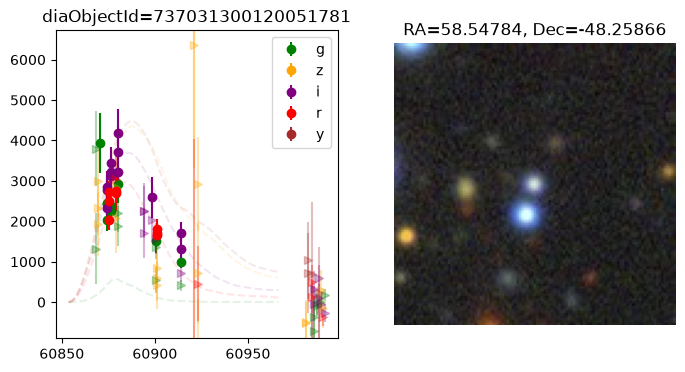

{'x0': np.float64(9.568247672805956e-06), 'x1': np.float64(0.5521513930218288), 'c': np.float64(0.20204815059689837), 'z': np.float64(0.3267746392617822), 'mwebv': np.float64(0.005737510575012076), 't0': np.float64(60885.91626659762)}
0.26801779943314025


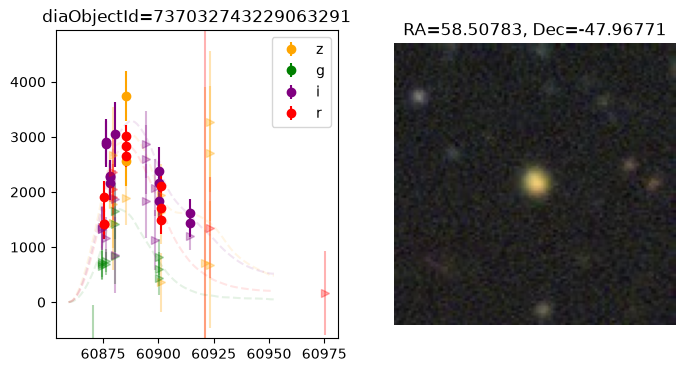

{'x0': np.float64(1.3679140981350132e-05), 'x1': np.float64(-3.944218921425503), 'c': np.float64(0.1440484558154752), 'z': np.float64(0.349452919864464), 'mwebv': np.float64(0.010413710594626566), 't0': np.float64(60876.3085492149)}
0.24608639734021465


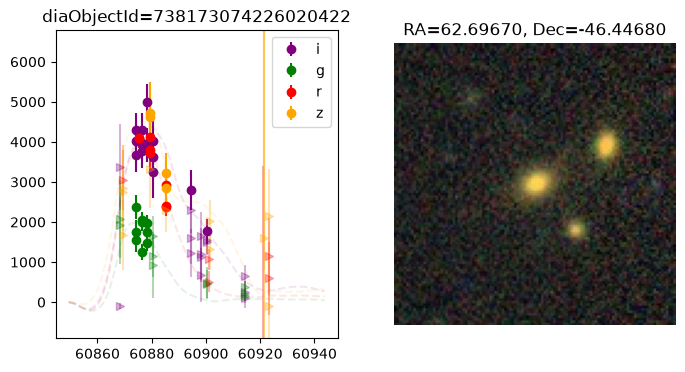

{'x0': np.float64(8.835928379043569e-06), 'x1': np.float64(3.684777799821514), 'c': np.float64(0.03540503169145016), 'z': np.float64(0.4707598119654814), 'mwebv': np.float64(0.010707798240124218), 't0': np.float64(60865.02555897539)}
0.9564935579576106


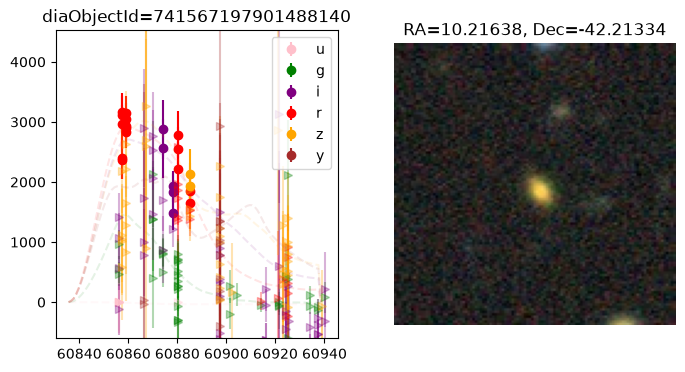

{'x0': np.float64(2.6287100210654286e-05), 'x1': np.float64(0.7175683315818113), 'c': np.float64(-0.033252743127108145), 'z': np.float64(0.37026116208288473), 'mwebv': np.float64(0.01016156967193662), 't0': np.float64(60879.675191931456)}
0.46319964345887726


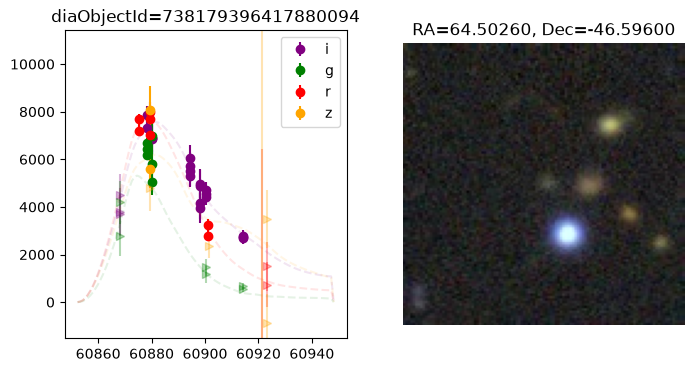

{'x0': np.float64(1.223674213052702e-05), 'x1': np.float64(0.675299947453955), 'c': np.float64(-0.0652920597108319), 'z': np.float64(0.3488042818956196), 'mwebv': np.float64(0.007691000485669668), 't0': np.float64(60879.3756288507)}
1.0098576711778744


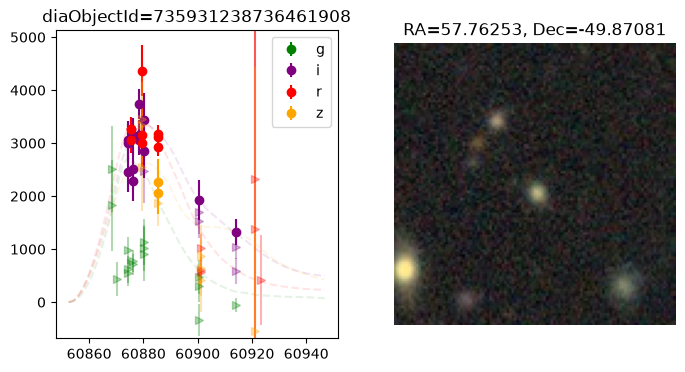

{'x0': np.float64(9.17758714161831e-06), 'x1': np.float64(-0.15007660343913817), 'c': np.float64(-0.33074184699788123), 'z': np.float64(0.9028893980569992), 'mwebv': np.float64(0.011774332331911105), 't0': np.float64(60885.710493604274)}
0.6296082193001742


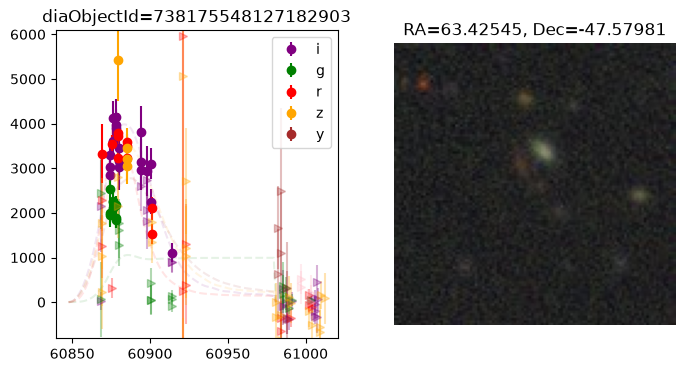

{'x0': np.float64(2.3303367245876122e-05), 'x1': np.float64(-0.7583496974247433), 'c': np.float64(0.05500398189048073), 'z': np.float64(0.30623217833520705), 'mwebv': np.float64(0.011458125387886417), 't0': np.float64(60868.83982576348)}
0.5214371762967684


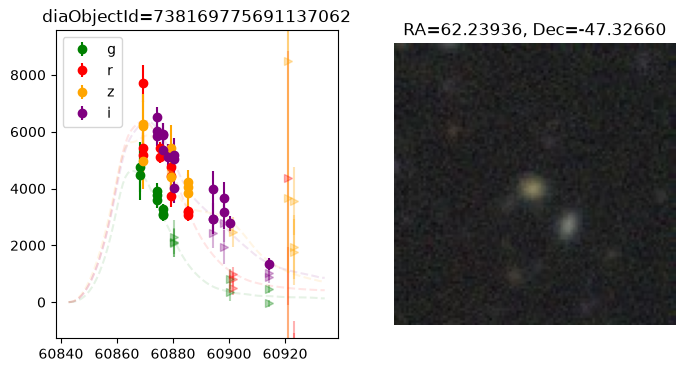

{'x0': np.float64(7.716702735940079e-06), 'x1': np.float64(2.340067926599758), 'c': np.float64(-0.22987028809053447), 'z': np.float64(0.8684133347923393), 'mwebv': np.float64(0.006334489772994117), 't0': np.float64(60878.782229606375)}
0.8074168005061205


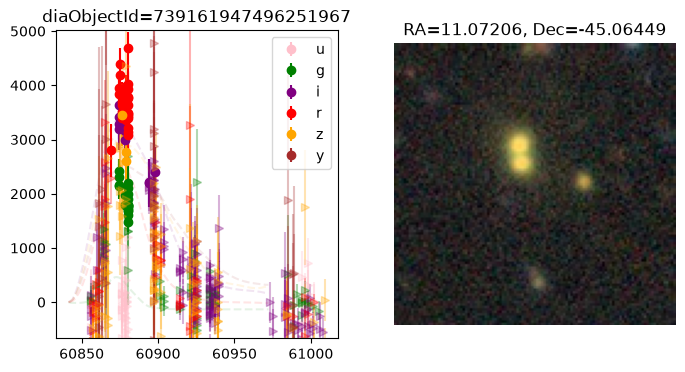

{'x0': np.float64(1.354157879217569e-05), 'x1': np.float64(0.7521113533775786), 'c': np.float64(-0.03491380949653069), 'z': np.float64(0.46837840260682556), 'mwebv': np.float64(0.010998395244091852), 't0': np.float64(60888.525842619056)}
0.6544023893364274


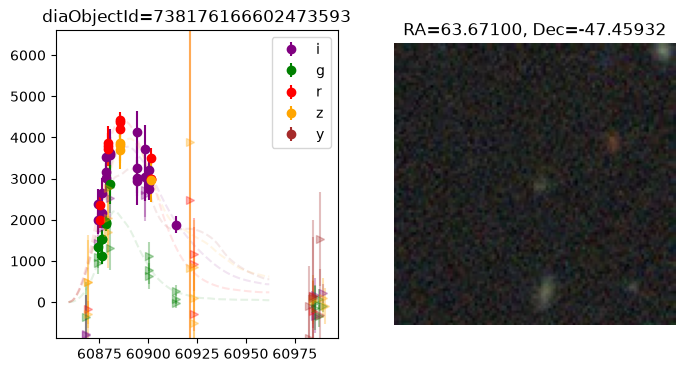

{'x0': np.float64(1.2908609153448556e-05), 'x1': np.float64(-1.607036957406024), 'c': np.float64(-0.05519822798185006), 'z': np.float64(0.4303188006581109), 'mwebv': np.float64(0.01091986343976989), 't0': np.float64(60884.48119550895)}
0.20667988404189036


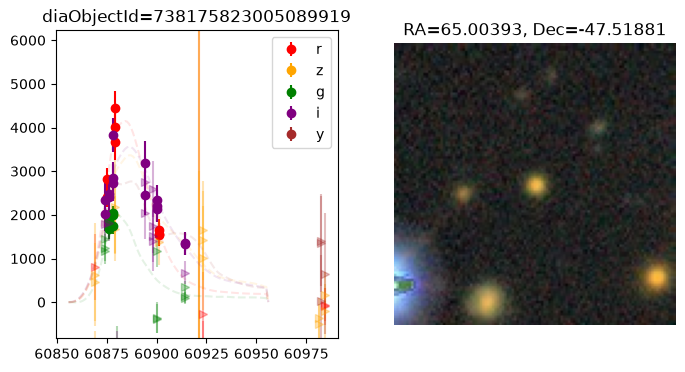

{'x0': np.float64(1.2469008921468277e-05), 'x1': np.float64(-2.3047954008790046), 'c': np.float64(-0.07521390173821174), 'z': np.float64(1.33994077794416), 'mwebv': np.float64(0.00891692341034751), 't0': np.float64(60864.28564496849)}
1.4630460262277278


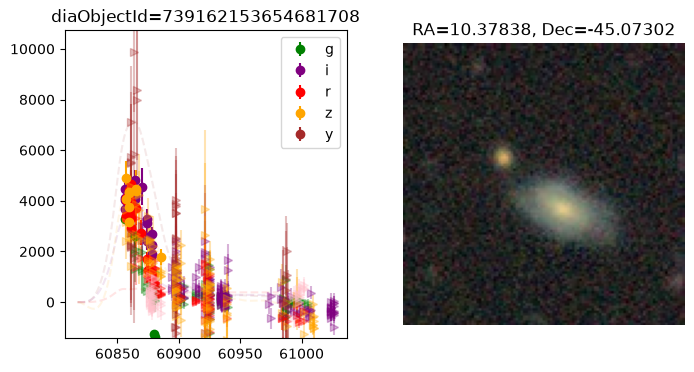

{'x0': np.float64(4.3221169845845165e-06), 'x1': np.float64(3.981709932537684), 'c': np.float64(-0.1917202350186114), 'z': np.float64(0.9161086892755363), 'mwebv': np.float64(0.005821578318745112), 't0': np.float64(60890.06599825284)}
0.33200991340677605


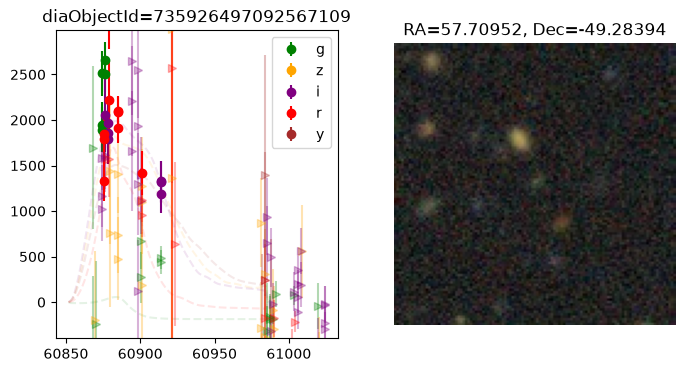

{'x0': np.float64(1.1472664113638692e-05), 'x1': np.float64(-0.28652031522780586), 'c': np.float64(2.16558618066068e-05), 'z': np.float64(0.3307063539663131), 'mwebv': np.float64(0.015790226234263037), 't0': np.float64(60886.87442576303)}
1.215449818759911


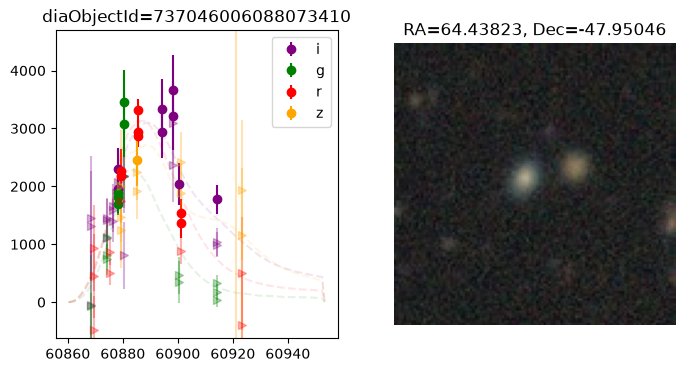

{'x0': np.float64(1.2233298517389386e-05), 'x1': np.float64(1.070762566305984), 'c': np.float64(-0.000963411551622627), 'z': np.float64(0.4220057834596253), 'mwebv': np.float64(0.010117373821229585), 't0': np.float64(60884.75452182153)}
0.12156998928006142


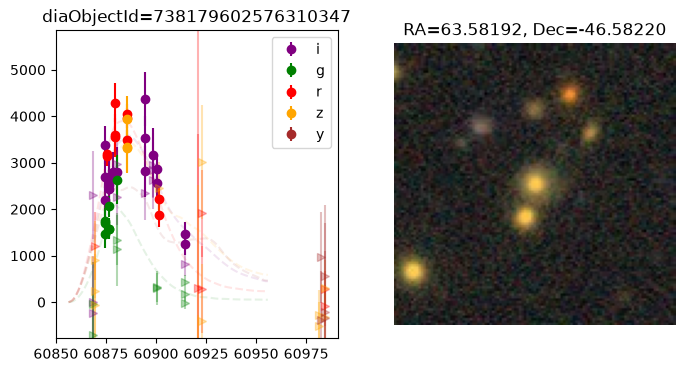

{'x0': np.float64(2.3210685747540817e-05), 'x1': np.float64(0.5002195237115229), 'c': np.float64(0.0037899297572638172), 'z': np.float64(0.32824159986516876), 'mwebv': np.float64(0.010027710626533777), 't0': np.float64(60870.443854948164)}
0.767377988001956


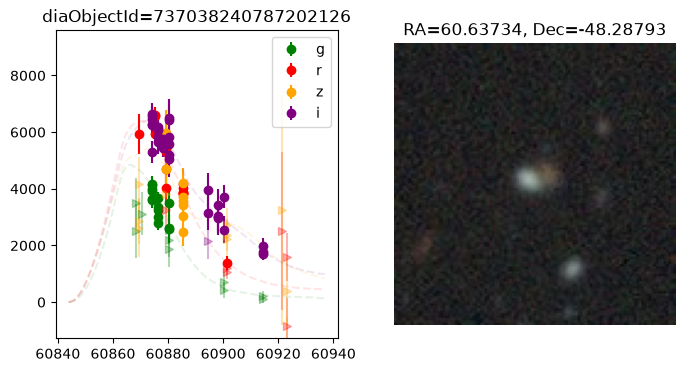

{'x0': np.float64(7.159819915682255e-06), 'x1': np.float64(0.407978891108432), 'c': np.float64(0.04773007643058666), 'z': np.float64(0.4732831813229326), 'mwebv': np.float64(0.008049945325156153), 't0': np.float64(60867.1479490101)}
1.0864463266201645


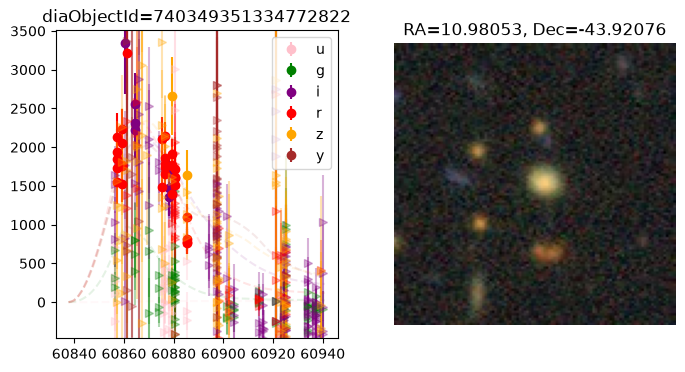

{'x0': np.float64(9.503889341110285e-06), 'x1': np.float64(-0.14166382440794534), 'c': np.float64(-0.10085123319829331), 'z': np.float64(0.5598968669479908), 'mwebv': np.float64(0.005087437832991994), 't0': np.float64(60878.87867966089)}
0.947919399890483


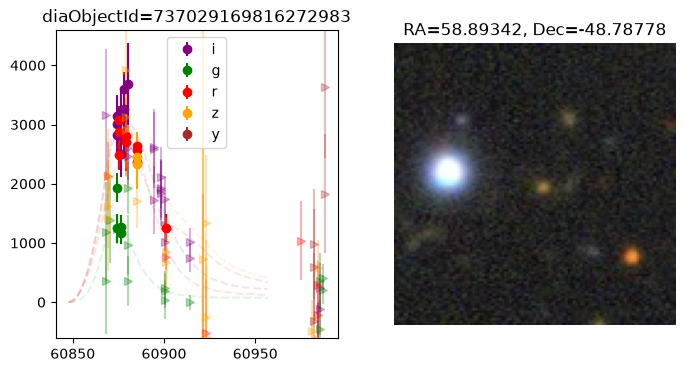

In [47]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([50,len(sn)]),replace=False):
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print(sn.iloc[i]["_dist_arcsec"])
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -20) & (phase < 70)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax = plt.subplot(1,2,2)
    ra = sn.iloc[i]["ra_dia_object_lc"]
    dec = sn.iloc[i]["dec_dia_object_lc"]
    img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [46]:
print(list(sn["diaObjectId_dia_object_lc"]))

[737042707553190055, 737046006088073410, 737053977547374632, 738175823005089919, 735931238736461908, 735926497092567109, 737042226516852836, 737046418404933649, 738175548127182903, 738169775691137062, 737038240787202126, 737029169816272983, 737031300120051781, 737032743229063291, 738176166602473593, 738179396417880094, 738179602576310347, 738173074226020422, 739162153654681708, 739161947496251967, 739162222374158392, 740354642734481547, 740349351334772822, 741565686073000096, 740345022007739546, 741567197901488140]
